In [1]:
import pickle

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [4]:
import os
import argparse

os.environ["CUDA_VISIBLE_DEVICES"] = "3"

import sys

sys.path.append("../src")
sys.path.append("../config")

from data_process import load_wls_adress_AddDomain
from process_SHAC import load_process_SHAC
from process_CD import load_cd
from process_HateSpeech import load_HateSpeech_dynGen, load_HateSpeech_wsf
from sampling_numbers import HateSpeech_DICT, SHAC_DICT, CD_DICT

from tqdm.auto import tqdm
import numpy as np
import pandas as pd

import torch
from transformers import (
    Trainer,
    TrainingArguments,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainerCallback,
    default_data_collator,
)
from scipy.special import softmax
from accelerate.utils import load_and_quantize_model
import itertools

In [5]:
from utils import number_split, create_mix, appendMetrics


In [6]:
from sklearn.manifold import TSNE

In [7]:
def do_Inference_HiddenSpece(txts):
        df_in = tokenizer(
            list(txts),
            return_tensors="pt",
            max_length=globalconfig.max_seq_length,
            padding="max_length",
            truncation=True,
        )

        ret_ls = []
        lst = list(range(len(df_in["input_ids"])))
        n = args.batch_size
        idx_ls = [lst[i : i + n] for i in range(len(lst)) if i % n == 0]

        model.eval()
        with torch.no_grad():
            for idx in tqdm(idx_ls, file=open(log_f, "w")):
                ret_output = model.roberta(
                    input_ids=df_in["input_ids"][idx].to(globalconfig.device),
                    attention_mask=df_in["attention_mask"][idx].to(globalconfig.device),
                    output_hidden_states=True,
                    return_dict=True,
                    output_attentions=True,
                )

                ret_ls.append(ret_output[0][:,0,:].detach().cpu().numpy())



        return np.concatenate(ret_ls)

# Load Data & Model

In [112]:
### Main
# dataset_name = "CD"
# dataset_name = "HateSpeech"

# isample = 566
# # isample = 6621


dataset_name = "SHAC"


# isample = 1152
isample = 11063


# methodUsed = "noaug"
# methodUsed = "MMD"
# methodUsed = "GDRO"
# methodUsed = "GradientReverse"
methodUsed = "GradientReverse_ForDomainBed"

if dataset_name == "SHAC" and methodUsed == "MMD":
    ep = 6
else:
    ep = 3

if dataset_name == "SHAC":
    n_test_eval = 800
else:
    n_test_eval = 1000
    
if methodUsed == "noaug":
    weightsEdited=f"/bime-munin/xiruod/roberta-base_{dataset_name}-FullFT-noaug/n200/set-{isample}-epoch{ep}/pytorch_model.bin"
else:
    weightsEdited=f"/bime-munin/xiruod/{methodUsed}/roberta-base_{dataset_name}/n200/set-{isample}-epoch{ep}/pytorch_model.bin"


log_f = "../log/test.log"

In [113]:
class Args:
    model_name='roberta-base'
    weightsEdited = weightsEdited
    output_dir="~/Downloads/tmp"
    gpu="3"
    device="cuda:0"
    batch_size=8
    dataset=dataset_name

In [114]:
args = Args()

In [ ]:
class train_config:
    def __init__(self):
        self.quantization: bool = False


# tmp = [x for x in args.weightsEdited.split("/") if "set-" in x]
# # of form like set-1355-quantization-epoch3-llama-2-7B-loraR-8-gamma_1-added.pth
# name_pre = tmp[0].split(".pth")[0]
# # 7, 13, 70
# outdir = args.output_dir
# name_general = f"runningInferenceOnly"
# log_f = f"../log/{name_general}.log"

# os.makedirs(outdir, exist_ok=True)

globalconfig = train_config()
globalconfig.model_name = args.model_name
globalconfig.max_seq_length = 512
globalconfig.device = args.device

##### Tokenizer
tokenizer = AutoTokenizer.from_pretrained(globalconfig.model_name, use_fast=False)

# if args.cpuOps:
#     load_device = "cpu"
#     load_state_device = "cpu"
# else:
#     load_device = globalconfig.device
#     load_state_device = globalconfig.device
load_device = globalconfig.device
load_state_device = globalconfig.device

##### Load Model and  Update using Edited Weights
model = AutoModelForSequenceClassification.from_pretrained(
    globalconfig.model_name,
    use_safetensors=False,
)

# this step cannot be ignored here...

if methodUsed in ["GradientReverse", "GradientReverse_ForDomainBed"]:
    tmp = torch.load(
        args.weightsEdited,
        map_location="cpu",
        # map_location=lambda storage, loc: storage,
    )

    key_ToRemove = ["classifierDomain.dense.weight", 
                    "classifierDomain.dense.bias", 
                    "classifierDomain.out_proj.weight", 
                    "classifierDomain.out_proj.bias",
                   ]

    for _ in key_ToRemove:
        del tmp[_]
else:
    tmp = torch.load(
        args.weightsEdited,
        map_location="cpu",
        # map_location=lambda storage, loc: storage,
    )
    

# this step cannot be ignored here...
model.load_state_dict(
    tmp
)




model = model.to(globalconfig.device)

print("###  Finished Loading...")

# if args.quantization:
#     bnb_quantization_config = BnbQuantizationConfig(
#         load_in_8bit=True, llm_int8_threshold=6
#     )
#     model = load_and_quantize_model(
#         model,
#         weights_location=args.weightsEdited,
#         bnb_quantization_config=bnb_quantization_config,
#         device_map=load_device,
#     )

# print("###  Finished Quantization...")

/home/NETID/xiruod/anaconda3/envs/llama2/lib/python3.9/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.dense.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
if dataset_name == "CD":
    df_all = load_cd()
    df_avh = df_all["avh"]
    df_r56 = df_all["r56"]

    txt_col = "text"

    z_Categories = ["avh","r56"] 

    domain_col = "dfSource"
    df_split_label = "label_binary"
    y_Categories = [0, 1]

    labels = ["Negative", "Positive"]
    
elif dataset_name == "HateSpeech":
    df_dynGen = load_HateSpeech_dynGen()
    df_wsf = load_HateSpeech_wsf()

    txt_col = "text"
    
    z_Categories = ["dynGen","wsf"] 
    df_split_label = "label_binary"
    y_Categories = [0, 1]

    domain_col = "dfSource"
    labels = ["Negative", "Positive"]

elif dataset_name == "SHAC":
#     df_dynGen = load_HateSpeech_dynGen()
#     df_wsf = load_HateSpeech_wsf()

    df_shac = load_process_SHAC(replaceNA="all")
    domain_col = "location"
    label = "Drug"

    df_shac = load_process_SHAC(replaceNA="all")
    df_shac["label_binary"] = df_shac.apply(lambda x: 1 if x[label] else 0, axis=1)
    df_shac["dfSource"] = df_shac[domain_col]
    
    df_shac_uw = df_shac.query("location == 'uw'").reset_index(drop=True)
    df_shac_mimic = df_shac.query("location == 'mimic'").reset_index(drop=True)
        
    txt_col = "text"
    
    df_split_label = "label_binary"
    y_Categories = [0, 1]
    
    z_Categories = ["uw", "mimic"] 

    labels = ["Negative", "Positive"]

# Select a balance set

In [ ]:
pick_C = isample
n_test = 200
label = "label_binary"

if dataset_name == "CD":
    df0 = df_avh
    df1 = df_r56
    c = CD_DICT[f"c_n{n_test}_{pick_C}"]
    
elif dataset_name == "HateSpeech":
    df0 = df_dynGen
    df1 = df_wsf

    c = HateSpeech_DICT[f"c_n{n_test}_{pick_C}"]
    
elif dataset_name == "SHAC":
    df0 = df_shac_uw
    df1 = df_shac_mimic

    c = SHAC_DICT[f"c_n{n_test}_{pick_C}"]



dfs_used = create_mix(
    df0=df0,
    df1=df1,
    target=label,
    setting=c,
    sample=False,
    # seed=random.randint(0,1000),
    seed=222,
)

df0 = df0[~df0[txt_col].isin(dfs_used["train"][txt_col])].reset_index(drop=True)
df0 = df0[~df0[txt_col].isin(dfs_used["test"][txt_col])].reset_index(drop=True)


df1 = df1[~df1[txt_col].isin(dfs_used["train"][txt_col])].reset_index(drop=True)
df1 = df1[~df1[txt_col].isin(dfs_used["test"][txt_col])].reset_index(drop=True)


balanced_setting = number_split(
        p_pos_train_z0=0.3,
        p_pos_train_z1=0.3,
        p_mix_z1=0.5,
        alpha_test=1,
        train_test_ratio=1,
        n_test=n_test_eval,
        verbose=False,
    )

In [ ]:
balanced_setting

In [ ]:
c = balanced_setting.copy()
c["n_train"] = 0
c["n_z0_pos_train"] = 1
c["n_z0_neg_train"] = 1
c["n_z1_pos_train"] = 1
c["n_z1_neg_train"] = 1
c["mix_param_dict"]["p_pos_train_z0"] = 0
c["mix_param_dict"]["p_pos_train_z1"] = 0
c["mix_param_dict"]["p_pos_train"] = 0
c["mix_param_dict"]["alpha_train"] = 0

# create train/test split according to stats
dfs = create_mix(df0=df0, df1=df1, target=label, setting=c, sample=False, seed=222)

In [ ]:
dfs['test'].groupby("dfSource")[label].sum()

In [ ]:
dfs['test'].groupby("dfSource").size()

In [ ]:
dfs['test']

# Do Inference

In [ ]:
array_hidden = do_Inference_HiddenSpece(dfs["test"][txt_col])

In [ ]:
array_hidden.shape

# t-SNE

In [ ]:
sns.reset_defaults()
sns.set_theme(style="ticks", rc={"figure.dpi": 350})


In [ ]:
X_embedded = TSNE(n_components=2, learning_rate='auto', perplexity=30).fit_transform(array_hidden)

In [ ]:
print(methodUsed)
print(isample)

In [ ]:
# df = pd.DataFrame({"d1":X_embedded[:,0],
#                    "d2":X_embedded[:,1],
#                    "domain": dfs["test"][domain_col],
#                    "target": dfs["test"][df_split_label]
                   
#                   })

# sns.scatterplot(data=df, x="d1", y="d2", hue='domain', style="target", alpha=0.6)

In [ ]:
z_Categories

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(8,8), sharey=True)

c_lst = ['orange', 'blue']


z_DICT = {"avh":"AVH",
          "r56": "TM",
          "wsf": "WSF",
          "dynGen": "dynGEN",
          "uw": "UW",
          "mimic":"MIMIC",
         }

for _idx, (_z,_y) in enumerate(zip(z_Categories, y_Categories)):
    
    _label = z_DICT[_z]        
        
    _select = (dfs["test"][domain_col] == _z)
    ax.scatter(X_embedded[_select,0], X_embedded[_select,1], alpha=.5, c=c_lst[_idx],  label=_label)

ax.legend()

plt.show()

# Plot All

In [8]:
sns.reset_defaults()
sns.set_theme(style="ticks", rc={"figure.dpi": 350})


In [9]:
title_DICT = {"noaug":"baseline", "MMD":"MMD", "GDRO":"GDRO", "GradientReverse":"DANN"}
# title_DICT = {"noaug":"baseline", "MMD":"MMD", "GDRO":"GDRO", "GradientReverse":"DANN", "GradientReverse_ForDomainBed":"DANN-DB"}

In [16]:
np.random.seed(184) # for t-SNE

savefig = True
# savefig = False



for dtlist, setls in itertools.product(['CD','HateSpeech'], [566, 6621]):
# for dtlist, setls in itertools.product(['SHAC'], [1152, 11063]):
    plt.clf()
    fig, axes = plt.subplots(2,2, figsize=(16,16), sharey=False, sharex=False)
    # fig, axes = plt.subplots(3,2, figsize=(24,16), sharey=False, sharex=False)

    axes = axes.ravel()

    for _idxOverall,(dataset_name, isample, methodUsed) in enumerate(itertools.product([dtlist], [setls], ["noaug",  "GradientReverse", "MMD", "GDRO",])):

        if dataset_name == "SHAC" and methodUsed == "MMD":
            ep = 6
        else:
            ep = 3

        if dataset_name == "SHAC":
            n_test_eval = 800
        else:
            n_test_eval = 1000

        outname = f"../output/MMD_GDRO_GradReverse_Figs/RoBERTa/fig-tSNE-{dataset_name}-set_{isample}-balencedSet.png"


        log_f = "../log/test.log"


        class Args:
            model_name='roberta-base'
            if methodUsed == "noaug":
                weightsEdited=f"/bime-munin/xiruod/roberta-base_{dataset_name}-FullFT-noaug/n200/set-{isample}-epoch{ep}/pytorch_model.bin"
            else:
                weightsEdited=f"/bime-munin/xiruod/{methodUsed}/roberta-base_{dataset_name}/n200/set-{isample}-epoch{ep}/pytorch_model.bin"
            output_dir="~/Downloads/tmp"
            gpu="3"
            device="cuda:0"
            batch_size=8
            dataset=dataset_name

        args = Args()

        class train_config:
            def __init__(self):
                self.quantization: bool = False


        globalconfig = train_config()
        globalconfig.model_name = args.model_name
        globalconfig.max_seq_length = 512
        globalconfig.device = args.device


        load_device = globalconfig.device
        load_state_device = globalconfig.device

        ##### Tokenizer
        tokenizer = AutoTokenizer.from_pretrained('roberta-base', use_fast=False)



        ##### Load Model and  Update using Edited Weights
        model = AutoModelForSequenceClassification.from_pretrained(
            globalconfig.model_name,
            use_safetensors=False,
        )

        # this step cannot be ignored here...

        if methodUsed == "GradientReverse":
            tmp = torch.load(
                args.weightsEdited,
                map_location="cpu",
                # map_location=lambda storage, loc: storage,
            )

            key_ToRemove = ["classifierDomain.dense.weight", 
                            "classifierDomain.dense.bias", 
                            "classifierDomain.out_proj.weight", 
                            "classifierDomain.out_proj.bias",
                           ]

            for _ in key_ToRemove:
                del tmp[_]
        else:
            tmp = torch.load(
                args.weightsEdited,
                map_location="cpu",
                # map_location=lambda storage, loc: storage,
            )


        # this step cannot be ignored here...
        model.load_state_dict(
            tmp
        )




        model = model.to(globalconfig.device)

        print("###  Finished Loading...")



        if dataset_name == "CD":
            df_all = load_cd()
            df_avh = df_all["avh"]
            df_r56 = df_all["r56"]

            txt_col = "text"

            z_Categories = ["avh","r56"] 

            domain_col = "dfSource"
            df_split_label = "label_binary"
            y_Categories = [0, 1]

            labels = ["Negative", "Positive"]

        elif dataset_name == "HateSpeech":
            df_dynGen = load_HateSpeech_dynGen()
            df_wsf = load_HateSpeech_wsf()

            txt_col = "text"

            z_Categories = ["dynGen","wsf"] 
            df_split_label = "label_binary"
            y_Categories = [0, 1]

            domain_col = "dfSource"
            labels = ["Negative", "Positive"]

        elif dataset_name == "SHAC":
        #     df_dynGen = load_HateSpeech_dynGen()
        #     df_wsf = load_HateSpeech_wsf()

            df_shac = load_process_SHAC(replaceNA="all")
            domain_col = "location"
            label = "Drug"

            df_shac = load_process_SHAC(replaceNA="all")
            df_shac["label_binary"] = df_shac.apply(lambda x: 1 if x[label] else 0, axis=1)
            df_shac["dfSource"] = df_shac[domain_col]

            df_shac_uw = df_shac.query("location == 'uw'").reset_index(drop=True)
            df_shac_mimic = df_shac.query("location == 'mimic'").reset_index(drop=True)

            txt_col = "text"

            df_split_label = "label_binary"
            y_Categories = [0, 1]

            z_Categories = ["uw", "mimic"] 

            labels = ["Negative", "Positive"]


        pick_C = isample
        n_test = 200
        label = "label_binary"

        if dataset_name == "CD":
            df0 = df_avh
            df1 = df_r56
            c = CD_DICT[f"c_n{n_test}_{pick_C}"]

        elif dataset_name == "HateSpeech":
            df0 = df_dynGen
            df1 = df_wsf

            c = HateSpeech_DICT[f"c_n{n_test}_{pick_C}"]

        elif dataset_name == "SHAC":
            df0 = df_shac_uw
            df1 = df_shac_mimic

            c = SHAC_DICT[f"c_n{n_test}_{pick_C}"]



        dfs_used = create_mix(
            df0=df0,
            df1=df1,
            target=label,
            setting=c,
            sample=False,
            # seed=random.randint(0,1000),
            seed=222,
        )

        df0 = df0[~df0[txt_col].isin(dfs_used["train"][txt_col])].reset_index(drop=True)
        df0 = df0[~df0[txt_col].isin(dfs_used["test"][txt_col])].reset_index(drop=True)


        df1 = df1[~df1[txt_col].isin(dfs_used["train"][txt_col])].reset_index(drop=True)
        df1 = df1[~df1[txt_col].isin(dfs_used["test"][txt_col])].reset_index(drop=True)


        balanced_setting = number_split(
                p_pos_train_z0=0.3,
                p_pos_train_z1=0.3,
                p_mix_z1=0.5,
                alpha_test=1,
                train_test_ratio=1,
                n_test=n_test_eval,
                verbose=False,
            )

        c = balanced_setting.copy()
        c["n_train"] = 0
        c["n_z0_pos_train"] = 1
        c["n_z0_neg_train"] = 1
        c["n_z1_pos_train"] = 1
        c["n_z1_neg_train"] = 1
        c["mix_param_dict"]["p_pos_train_z0"] = 0
        c["mix_param_dict"]["p_pos_train_z1"] = 0
        c["mix_param_dict"]["p_pos_train"] = 0
        c["mix_param_dict"]["alpha_train"] = 0

        # create train/test split according to stats
        dfs = create_mix(df0=df0, df1=df1, target=label, setting=c, sample=False, seed=222)

        array_hidden = do_Inference_HiddenSpece(dfs["test"][txt_col])

        print(array_hidden.shape)

        X_embedded = TSNE(n_components=2, learning_rate='auto', perplexity=30).fit_transform(array_hidden)

        print(methodUsed)
        print(isample)




        c_lst = ['orange', 'blue']


        z_DICT = {"avh":"AVH",
                  "r56": "TM",
                  "wsf": "WSF",
                  "dynGen": "dynGEN",
                  "uw": "UW",
                  "mimic":"MIMIC",
                 }

        for _idx, (_z,_y) in enumerate(zip(z_Categories, y_Categories)):

            _label = z_DICT[_z]        

            _select = (dfs["test"][domain_col] == _z)
            axes[_idxOverall].scatter(X_embedded[_select,0], X_embedded[_select,1], alpha=.5, c=c_lst[_idx],  label=_label)

        axes[_idxOverall].legend(fontsize=20, markerscale=3)

        axes[_idxOverall].set_title(title_DICT[methodUsed], fontweight="bold", 
                                    size=30) 

        # axes[_idxOverall].title.set_text(r"$\bf{" + title_DICT[methodUsed]+ "}$")
        # axes[_idxOverall].tick_params(axis='x', labelsize=6)
        # axes[_idxOverall].tick_params(axis='y', labelsize=6)
        # axes[_idxOverall].set_xticks([])
        # axes[_idxOverall].set_yticks([]) 


    if savefig:
        plt.savefig(outname, dpi=600, bbox_inches='tight')
    else:
        plt.show()
        
    plt.clf()




/home/NETID/xiruod/anaconda3/envs/llama2/lib/python3.9/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.out_proj.bias', 'classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


###  Finished Loading...


  0%|          | 0/125 [00:00<?, ?it/s]

(1000, 768)
noaug
566


/home/NETID/xiruod/anaconda3/envs/llama2/lib/python3.9/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.out_proj.bias', 'classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

<Figure size 2240x1680 with 0 Axes>

<Figure size 5600x5600 with 0 Axes>

<Figure size 5600x5600 with 0 Axes>

<Figure size 5600x5600 with 0 Axes>

<Figure size 5600x5600 with 0 Axes>

# Separation Metric

Inherit from "Do Inference" Section

## Classifier two-sample test (C2ST)

In [21]:
!pip list | grep jupyter

jupyter                   1.0.0
jupyter_client            7.4.9
jupyter-console           6.6.3
jupyter_core              5.3.1
jupyter-events            0.7.0
jupyter-lsp               2.2.0
jupyter-server            1.24.0
jupyter_server_fileid     0.9.0
jupyter_server_terminals  0.4.4
jupyter_server_ydoc       0.8.0
jupyter-ydoc              0.2.5
jupyterlab                3.6.5
jupyterlab-execute-time   2.0.5
jupyterlab-lsp            4.2.0
jupyterlab-pygments       0.2.2
jupyterlab_server         2.24.0
jupyterlab-widgets        3.0.8


In [22]:
dfs["test"][domain_col]

0         uw
1         uw
2         uw
3         uw
4         uw
       ...  
795    mimic
796    mimic
797    mimic
798    mimic
799    mimic
Name: location, Length: 800, dtype: object

In [23]:
array_hidden.shape

(800, 768)

In [24]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    accuracy_score, f1_score
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.decomposition import PCA


In [25]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    accuracy_score, f1_score
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


# ---------------------------
# Simple MLP with dropout
# ---------------------------
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, dropout_p=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


# ---------------------------
# Train MLP with early stopping and plotting
# ---------------------------
def train_mlp(X_train, y_train, X_val, y_val,
              hidden_dim=32, dropout_p=0.2, lr=1e-3,
              weight_decay=1e-4, epochs=100, batch_size=64,
              patience=10, fold_id=1, verbose=False):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = SimpleMLP(X_train.shape[1], hidden_dim=hidden_dim, dropout_p=dropout_p).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCEWithLogitsLoss()

    Xtr = torch.tensor(X_train, dtype=torch.float32).to(device)
    ytr = torch.tensor(y_train, dtype=torch.float32).to(device)
    Xva = torch.tensor(X_val, dtype=torch.float32).to(device)
    yva = torch.tensor(y_val, dtype=torch.float32).to(device)

    best_val_loss = float('inf')
    best_probs = None
    counter = 0

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # Training
        model.train()
        perm = torch.randperm(len(Xtr))
        for i in range(0, len(Xtr), batch_size):
            idx = perm[i:i+batch_size]
            xb, yb = Xtr[idx], ytr[idx]
            logits = model(xb)
            loss = loss_fn(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        with torch.no_grad():
            val_logits = model(Xva)
            val_loss = loss_fn(val_logits, yva).item()
            train_loss = loss_fn(model(Xtr), ytr).item()
            probs = torch.sigmoid(val_logits).cpu().numpy()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_probs = probs.copy()
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                if verbose:
                    print(f"Fold {fold_id}: Early stopping at epoch {epoch+1}")
                break

    # Plot train vs val loss
    plt.figure(figsize=(6,4))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('BCE Loss')
    plt.title(f'Train vs Validation Loss (Fold {fold_id})')
    plt.legend()
    plt.show()

    return best_probs


# ---------------------------
# C2ST with PCA, logistic regression, or MLP
# ---------------------------
def c2st_cv(X, z_Categories, domain_col=None,
            n_splits=5, classifier="logreg", random_state=0,
            threshold=0.5, pca_variance=None,
            # MLP hyperparams
            hidden_dim=32, dropout_p=0.2, lr=1e-3,
            weight_decay=1e-4, epochs=100, batch_size=64,
            patience=10, verbose=False):
    
    # Extract labels
    if domain_col is not None:
        y_raw = z_Categories[domain_col].values
    else:
        y_raw = np.array(z_Categories)

    le = LabelEncoder()
    y = le.fit_transform(y_raw)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    auprcs, aurocs, accs, f1s = [], [], [], []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        Xt_tr, Xt_val = X[train_idx], X[val_idx]
        yt_tr, yt_val = y[train_idx], y[val_idx]

        # Standardize
        scaler = StandardScaler().fit(Xt_tr)
        Xt_tr_s = scaler.transform(Xt_tr)
        Xt_val_s = scaler.transform(Xt_val)

        # PCA if specified
        if pca_variance is not None:
            pca = PCA(n_components=pca_variance).fit(Xt_tr_s)
            Xt_tr_s = pca.transform(Xt_tr_s)
            Xt_val_s = pca.transform(Xt_val_s)
            print(f"PCA Applied. {pca_variance*100}% of variance explained by {Xt_tr_s.shape[1]} components")

        # Train classifier
        if classifier == "logreg":
            clf = LogisticRegression(penalty="l2", solver="lbfgs", max_iter=2000)
            clf.fit(Xt_tr_s, yt_tr)
            probs = clf.predict_proba(Xt_val_s)[:, 1]

        elif classifier == "mlp":
            probs = train_mlp(
                Xt_tr_s, yt_tr, Xt_val_s, yt_val,
                hidden_dim=hidden_dim, dropout_p=dropout_p,
                lr=lr, weight_decay=weight_decay,
                epochs=epochs, batch_size=batch_size,
                patience=patience, fold_id=fold, verbose=verbose
            )

        else:
            raise ValueError("Classifier must be 'logreg' or 'mlp'")

        preds = (probs >= threshold).astype(int)

        # Metrics
        auprcs.append(average_precision_score(yt_val, probs))
        aurocs.append(roc_auc_score(yt_val, probs))
        accs.append(accuracy_score(yt_val, preds))
        f1s.append(f1_score(yt_val, preds))

        if verbose and classifier=="logreg":
            print(f"Fold {fold}: AUPRC={auprcs[-1]:.3f}, AUROC={aurocs[-1]:.3f}, "
                  f"Acc={accs[-1]:.3f}, F1={f1s[-1]:.3f}\n")

    return {
        "cv_mean_auprc": float(np.mean(auprcs)),
        "cv_std_auprc": float(np.std(auprcs)),
        "cv_mean_auroc": float(np.mean(aurocs)),
        "cv_std_auroc": float(np.std(aurocs)),
        "cv_mean_acc": float(np.mean(accs)),
        "cv_std_acc": float(np.std(accs)),
        "cv_mean_f1": float(np.mean(f1s)),
        "cv_std_f1": float(np.std(f1s)),
        "classes": le.classes_.tolist()
    }


In [26]:
print(dataset_name)

print(isample)

print(methodUsed)

SHAC
1152
GradientReverse


In [27]:
# Case 1: labels in a plain list/array


results = c2st_cv(array_hidden, z_Categories=dfs['test'][domain_col],
                  classifier="logreg",
                  pca_variance=0.95,
                  threshold=0.5,)

formatted_results = {
    metric: f"{results[f'cv_mean_{metric}']:.3f} ± {results[f'cv_std_{metric}']:.3f}"
    for metric in ["auprc", "auroc", "acc", "f1"]
}

pd.DataFrame([formatted_results])

PCA Applied. 95.0% of variance explained by 2 components
PCA Applied. 95.0% of variance explained by 2 components
PCA Applied. 95.0% of variance explained by 2 components
PCA Applied. 95.0% of variance explained by 2 components
PCA Applied. 95.0% of variance explained by 2 components


,auprc,auroc,acc,f1
0,0.877 ± 0.045,0.933 ± 0.018,0.946 ± 0.009,0.948 ± 0.009


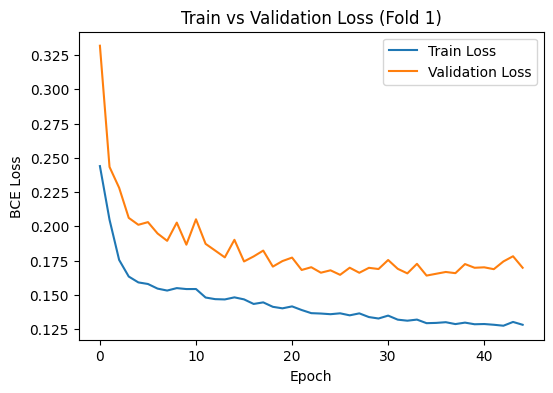

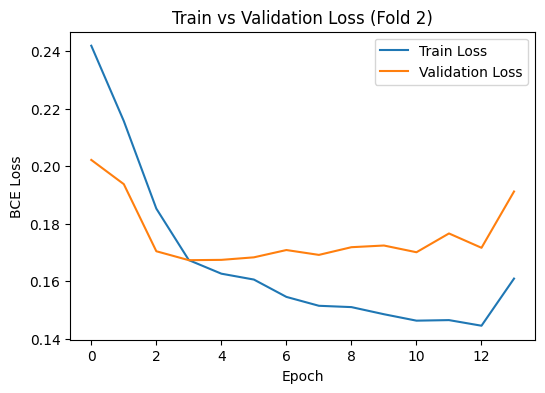

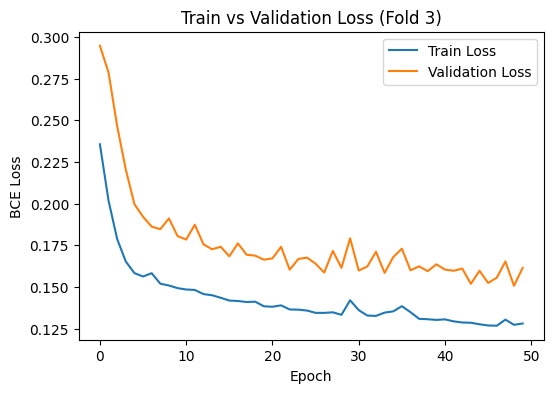

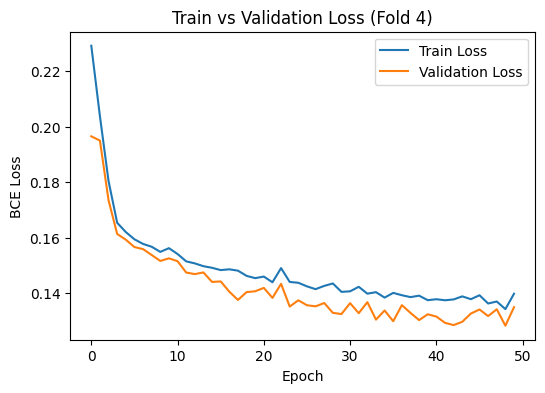

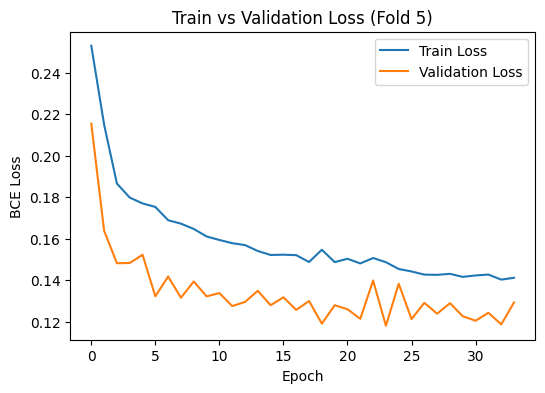

,auprc,auroc,acc,f1
0,0.985 ± 0.005,0.986 ± 0.004,0.949 ± 0.008,0.950 ± 0.008


In [28]:
# Case 2: labels stored in a DataFrame column
results = c2st_cv(array_hidden, z_Categories=dfs['test'][domain_col],  classifier="mlp", hidden_dim=64, epochs=50, threshold=0.5)

formatted_results = {
    metric: f"{results[f'cv_mean_{metric}']:.3f} ± {results[f'cv_std_{metric}']:.3f}"
    for metric in ["auprc", "auroc", "acc", "f1"]
}

pd.DataFrame([formatted_results])

## Fisher Ratio

In [29]:

def fisher_ratio(X, z_Categories, domain_col=None):
    """
    Compute Fisher ratio: between-class scatter / within-class scatter.

    Parameters
    ----------
    X : np.ndarray
        Feature embeddings (samples x features)
    z_Categories : list/array or DataFrame
        Labels (string or int). If DataFrame, specify `domain_col`.
    domain_col : str or None
        Column name if z_Categories is a DataFrame.

    Returns
    -------
    dict
        {
            "between_scatter": float,
            "within_scatter": float,
            "fisher_ratio": float
        }
    """
    # Extract labels
    if domain_col is not None:
        y_raw = z_Categories[domain_col].values
    else:
        y_raw = np.array(z_Categories)

    le = LabelEncoder()
    y = le.fit_transform(y_raw)
    classes = np.unique(y)
    
    overall_mean = np.mean(X, axis=0)

    # Between-class scatter
    Sb = 0
    # Within-class scatter
    Sw = 0

    for c in classes:
        Xc = X[y == c]
        mean_c = np.mean(Xc, axis=0)
        n_c = Xc.shape[0]

        Sb += n_c * np.sum((mean_c - overall_mean) ** 2)
        Sw += np.sum((Xc - mean_c) ** 2)

    fisher = Sb / Sw if Sw > 0 else np.inf

    return {
        "between_scatter": Sb,
        "within_scatter": Sw,
        "fisher_ratio": fisher
    }


In [26]:
print(dataset_name)

print(isample)

print(methodUsed)

SHAC
1152
GradientReverse


In [35]:
result = fisher_ratio(array_hidden, z_Categories=dfs['test'][domain_col])

print("Between-class scatter:", result["between_scatter"])
print("Within-class scatter:", result["within_scatter"])
print("Fisher ratio:", round(result["fisher_ratio"], 4))


Between-class scatter: 235633.30078125
Within-class scatter: 63871.6826171875
Fisher ratio: 3.6892


In [10]:
df = pd.read_csv("data/fisher_ratio_robustness.csv")

In [12]:
df.columns = ['robustness', 'fisher_ratio']

In [13]:
df

,robustness,fisher_ratio
0,0.199,0.1971
1,0.093,0.0118
2,0.209,0.1851
3,0.249,0.6319
4,0.210,0.2249
5,0.038,0.0251
6,0.147,0.0414
7,0.068,0.0845
8,0.240,0.5844
9,0.118,0.0341


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats



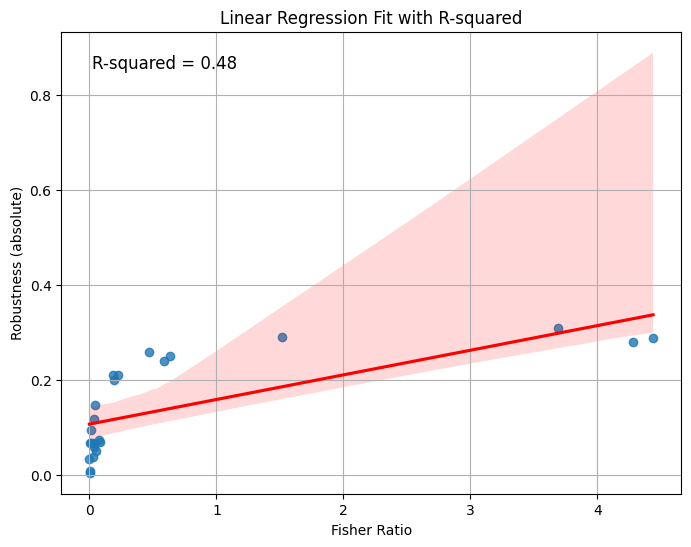

In [16]:
# 2. Perform linear regression and get R-squared
slope, intercept, r_value, p_value, std_err = stats.linregress(df['fisher_ratio'], df['robustness'])
r_squared = r_value**2

# 3. Plot the data and regression line using Seaborn
plt.figure(figsize=(8, 6))
sns.regplot(x='fisher_ratio', y='robustness', data=df, ci=95, line_kws={'color': 'red'})

# 4. Add the R-squared value to the plot
plt.text(x=0.05, y=0.95, s=f'R-squared = {r_squared:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

# 5. Customize the plot
plt.title('Linear Regression Fit with R-squared')
plt.xlabel('Fisher Ratio')
plt.ylabel('Robustness (absolute)')
plt.grid(True)
plt.show()

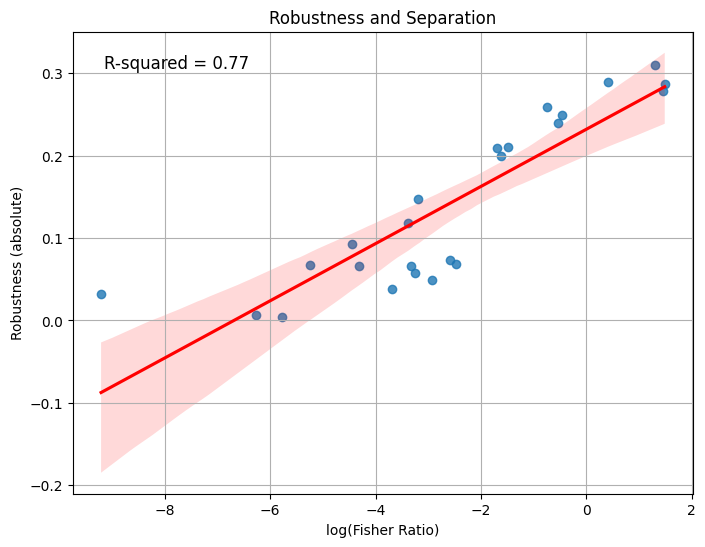

In [20]:

# 2. Perform linear regression and get R-squared
x = np.log(df['fisher_ratio'])
y = df['robustness']

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2

# 3. Plot the data and regression line using Seaborn
plt.figure(figsize=(8, 6))
sns.regplot(x=x, y=y, ci=95, line_kws={'color': 'red'})

# 4. Add the R-squared value to the plot
plt.text(x=0.05, y=0.95, s=f'R-squared = {r_squared:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

# 5. Customize the plot
plt.title('Robustness and Separation')
plt.xlabel('log(Fisher Ratio)')
plt.ylabel('Robustness (absolute)')
plt.grid(True)
plt.show()

## k-NN neighborhood homogeneity

In [43]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder

In [44]:
def knn_homogeneity(X, z_Categories, domain_col=None, k=10):
    """
    Compute k-NN neighborhood homogeneity as a measure of separability.

    Parameters
    ----------
    X : np.ndarray
        Feature embeddings (samples x features).
    z_Categories : list/array or DataFrame
        Provenance/domain labels.
    domain_col : str or None
        Column name if z_Categories is a DataFrame.
    k : int
        Number of neighbors (excluding self).

    Returns
    -------
    dict
        {
            "mean_homogeneity": float,
            "per_class_homogeneity": dict[class_label -> score],
            "k": int
        }
    """
    # Extract labels
    if domain_col is not None:
        y_raw = z_Categories[domain_col].values
    else:
        y_raw = np.array(z_Categories)

    le = LabelEncoder()
    y = le.fit_transform(y_raw)
    classes = le.classes_

    # Fit kNN
    nn_model = NearestNeighbors(n_neighbors=k+1, metric="euclidean")  # +1 includes self
    nn_model.fit(X)
    neigh_indices = nn_model.kneighbors(X, return_distance=False)[:, 1:]  # drop self

    # Compute homogeneity per sample
    homogeneity_scores = []
    for i in range(X.shape[0]):
        neighbors = neigh_indices[i]
        same_label_count = np.sum(y[neighbors] == y[i])
        homogeneity_scores.append(same_label_count / k)

    homogeneity_scores = np.array(homogeneity_scores)

    # Global average
    mean_homogeneity = float(np.mean(homogeneity_scores))

    # Per-class averages
    per_class = {}
    for idx, cls in enumerate(classes):
        per_class[cls] = float(np.mean(homogeneity_scores[y == idx]))

    return {
        "mean_homogeneity": mean_homogeneity,
        "per_class_homogeneity": per_class,
        "k": k
    }

In [45]:
result = knn_homogeneity(array_hidden, z_Categories=dfs['test'][domain_col], k=10)

print("Mean homogeneity:", result["mean_homogeneity"])
print("Per-class homogeneity:", result["per_class_homogeneity"])

Mean homogeneity: 0.8063750000000002
Per-class homogeneity: {'mimic': 0.8247500000000001, 'uw': 0.7880000000000001}


## Sliced Wasserstein Distance

In [46]:

from scipy.stats import wasserstein_distance
from itertools import combinations

In [47]:
def _one_fold_sw(Xa, Xb, n_projections=100, rng=None):
    """
    Compute sliced-Wasserstein (mean over projections) between two samples Xa, Xb.
    """
    dims = Xa.shape[1]
    vals = []
    for _ in range(n_projections):
        u = rng.normal(size=(dims,))
        u /= np.linalg.norm(u) + 1e-16
        pa = Xa.dot(u)
        pb = Xb.dot(u)
        vals.append(wasserstein_distance(pa, pb))
    vals = np.array(vals)
    return float(vals.mean()), float(vals.std()), vals

def sliced_wasserstein(
    X,
    z_Categories,
    domain_col=None,
    n_projections=100,
    random_state=0,
    n_splits=None
):
    """
    Compute sliced-Wasserstein separability for embeddings X with provenance labels.

    Parameters
    ----------
    X : np.ndarray, shape (n_samples, n_features)
        Embeddings/features.
    z_Categories : array-like or DataFrame
        Provenance/domain labels (strings or ints) or DataFrame if domain_col given.
    domain_col : str or None
        If z_Categories is a DataFrame, the column name containing labels.
    n_projections : int
        Number of random 1-D projections to average over (default 100).
    random_state : int
        RNG seed.
    n_splits : int or None
        If int, perform StratifiedKFold with this many folds and compute SW per fold.
        If None (default), compute on the full dataset.

    Returns
    -------
    dict with keys:
      - "mean_sw": float, mean sliced-Wasserstein (averaged across projections and across folds if CV)
      - "std_sw": float, std across projections (and folds combined)
      - "per_projection_values": np.ndarray of shape (n_projections,) when n_splits is None,
                                 or shape (n_splits, n_projections) when CV used
      - "n_projections": int
      - "classes": list of class labels (string)
      - "fold_sw_means": list of per-fold mean SW (if n_splits provided)
      - "pairwise": dict mapping pair -> (mean, std) when >2 classes
    """
    # Extract labels
    if domain_col is not None:
        y_raw = z_Categories[domain_col].values
    else:
        y_raw = np.array(z_Categories)

    le = LabelEncoder()
    y = le.fit_transform(y_raw)
    class_labels = le.classes_.tolist()
    unique = np.unique(y)
    rng = np.random.RandomState(random_state)

    # Helper: compute mean SW between two index sets
    def pair_sw(indices_a, indices_b):
        Xa = X[indices_a]
        Xb = X[indices_b]
        mean_val, std_val, vals = _one_fold_sw(Xa, Xb, n_projections=n_projections, rng=rng)
        return mean_val, std_val, vals

    # If no CV: compute on full set
    if n_splits is None:
        if len(unique) == 2:
            idx_a = np.where(y == unique[0])[0]
            idx_b = np.where(y == unique[1])[0]
            mean_val, std_val, vals = pair_sw(idx_a, idx_b)
            return {
                "mean_sw": mean_val,
                "std_sw": std_val,
                "per_projection_values": vals,
                "n_projections": n_projections,
                "classes": class_labels,
                "fold_sw_means": [mean_val],
                "pairwise": { (class_labels[0], class_labels[1]): (mean_val, std_val) }
            }
        else:
            # multi-class: average pairwise SW
            pairs = list(combinations(unique, 2))
            pairwise = {}
            all_vals = []
            means = []
            for (i,j) in pairs:
                idx_i = np.where(y == i)[0]
                idx_j = np.where(y == j)[0]
                m, s, vals = pair_sw(idx_i, idx_j)
                pairwise[(class_labels[i], class_labels[j])] = (m, s)
                all_vals.append(vals)
                means.append(m)
            all_vals = np.vstack(all_vals)  # shape (num_pairs, n_projections)
            # average across pairs then projections
            mean_sw = float(all_vals.mean())
            std_sw = float(all_vals.std())
            return {
                "mean_sw": mean_sw,
                "std_sw": std_sw,
                "per_projection_values": all_vals,  # pair x projection
                "n_projections": n_projections,
                "classes": class_labels,
                "fold_sw_means": [mean_sw],
                "pairwise": pairwise
            }

    # If CV requested: compute per-fold
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_vals = []
    fold_means = []
    pairwise_all_folds = []  # list of dicts per fold if multi-class

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        # compute SW on this fold's validation set (or you can choose train split; here val split)
        X_fold = X[val_idx]
        y_fold = y[val_idx]
        classes_fold = np.unique(y_fold)

        if len(classes_fold) < 2:
            # can't compute pairwise on this fold (rare if very imbalanced)
            fold_vals.append(np.zeros(n_projections))
            fold_means.append(0.0)
            pairwise_all_folds.append({})
            continue

        if len(classes_fold) == 2:
            ia = np.where(y_fold == classes_fold[0])[0]
            ib = np.where(y_fold == classes_fold[1])[0]
            # convert ia,ib to indices relative to X_fold and then map to global indices val_idx
            # we already have X_fold so use direct
            Xa = X_fold[ia]
            Xb = X_fold[ib]
            mean_val, std_val, vals = _one_fold_sw(Xa, Xb, n_projections=n_projections, rng=rng)
            fold_vals.append(vals)
            fold_means.append(mean_val)
            pairwise_all_folds.append({ (class_labels[classes_fold[0]], class_labels[classes_fold[1]]): (mean_val, std_val) })
        else:
            # multi-class: mean pairwise on this fold
            pairs = list(combinations(classes_fold, 2))
            all_pair_vals = []
            pairwise_fold = {}
            for (i,j) in pairs:
                ia = np.where(y_fold == i)[0]
                ib = np.where(y_fold == j)[0]
                Xa = X_fold[ia]; Xb = X_fold[ib]
                m,s,vals = _one_fold_sw(Xa, Xb, n_projections=n_projections, rng=rng)
                pairwise_fold[(class_labels[i], class_labels[j])] = (m,s)
                all_pair_vals.append(vals)
            all_pair_vals = np.vstack(all_pair_vals)
            fold_vals.append(all_pair_vals.mean(axis=0))  # fold-level projection values (averaged over pairs)
            fold_means.append(float(all_pair_vals.mean()))
            pairwise_all_folds.append(pairwise_fold)

    fold_vals = np.vstack(fold_vals)  # (n_splits, n_projections)
    mean_sw_overall = float(fold_vals.mean())
    std_sw_overall = float(fold_vals.std())

    return {
        "mean_sw": mean_sw_overall,
        "std_sw": std_sw_overall,
        "per_projection_values": fold_vals,
        "n_projections": n_projections,
        "classes": class_labels,
        "fold_sw_means": [float(m) for m in fold_means],
        "pairwise": pairwise_all_folds
    }

In [48]:
# Full-dataset (no CV), binary case
res = sliced_wasserstein(array_hidden, z_Categories=dfs['test'][domain_col], n_projections=200, random_state=0)
print("Mean SW:", res["mean_sw"], "Std SW:", res["std_sw"])



Mean SW: 0.13457047676248712 Std SW: 0.0786072389221309
